# Tech Challenge Fase 4

## Notebook 2: Treinamento do Modelo LSTM

**Objetivo:** Treinar uma rede neural LSTM para prever o preço de **fechamento** da PETR4.SA usando uma janela dos últimos N dias.

### 1. Instalar dependências

In [0]:
%pip install tensorflow==2.15.0 scikit-learn keras-tuner --quiet
dbutils.library.restartPython()

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.69.0 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


### 2. Parâmetros

In [0]:
dbutils.widgets.text("catalog", "jessyca_catalog", "Catalog")
dbutils.widgets.text("schema", "postech_fase4", "Schema")
dbutils.widgets.text("table", "precos_acoes", "Tabela")
dbutils.widgets.text("window_size", "60", "Janela (dias)")
dbutils.widgets.text("epochs", "25", "Épocas")
dbutils.widgets.text("batch_size", "32", "Batch size")

CATALOG     = dbutils.widgets.get("catalog")
SCHEMA      = dbutils.widgets.get("schema")
TABLE       = dbutils.widgets.get("table")
WINDOW      = int(dbutils.widgets.get("window_size"))
EPOCHS      = int(dbutils.widgets.get("epochs"))
BATCH_SIZE  = int(dbutils.widgets.get("batch_size"))

FULL_TABLE = f"{CATALOG}.{SCHEMA}.{TABLE}"
print(f"Tabela origem: {FULL_TABLE} | janela={WINDOW} | epochs={EPOCHS} | batch={BATCH_SIZE}")

Tabela origem: jessyca_catalog.postech_fase4.precos_acoes | janela=60 | epochs=25 | batch=32


### 3. Carregar e ordenar os dados

Criação de DataFrame Pandas ordenado por data.

In [0]:
import pandas as pd

df = (
    spark.table(FULL_TABLE)
    .select("date", "close")
    .orderBy("date")
    .toPandas()
)

df["date"] = pd.to_datetime(df["date"])
df = df.dropna().reset_index(drop=True)
print(f"Linhas: {len(df)}  | Período: {df['date'].min().date()} a {df['date'].max().date()}")
df.tail()

Linhas: 1988  | Período: 2018-01-02 a 2025-12-30


,date,close
1983,2025-12-22,31.100000
1984,2025-12-23,30.309999
1985,2025-12-26,30.410000
1986,2025-12-29,30.730000
1987,2025-12-30,30.820000


### 4. Gráfico do histórico

Visualização da série.

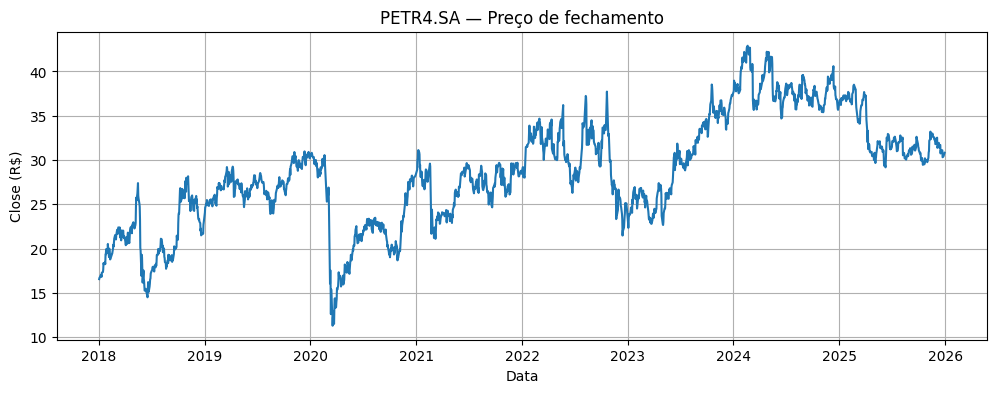

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["close"])
plt.title("PETR4.SA — Preço de fechamento")
plt.xlabel("Data"); plt.ylabel("Close (R$)")
plt.grid(True); plt.show()

### 5. Normalização (MinMaxScaler)

Transformar os preços para a faixa [0, 1]. O `scaler` foi salvo para ser usado na API para transformar novos inputs e depois para desfazer a transformação na predição.

In [0]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

prices = df["close"].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
prices_scaled = scaler.fit_transform(prices)

print(f"Min preço: {prices.min():.2f} | Max preço: {prices.max():.2f}")
print(f"Após scaling: min={prices_scaled.min():.4f}, max={prices_scaled.max():.4f}")

Min preço: 11.29 | Max preço: 42.90
Após scaling: min=0.0000, max=1.0000


### 6. Criar janelas (X, y)

Para cada posição `i`, `X` recebe os preços dos últimos `WINDOW` dias e `y` recebe o preço do dia `i`. O LSTM espera entrada com shape `(amostras, janela, features)`.

In [0]:
def criar_janelas(serie, window):
    X, y = [], []
    for i in range(window, len(serie)):
        X.append(serie[i - window : i, 0])
        y.append(serie[i, 0])
    return np.array(X), np.array(y)

X, y = criar_janelas(prices_scaled, WINDOW)
X = X.reshape((X.shape[0], X.shape[1], 1))  # (amostras, timesteps, features)
print(f"X shape: {X.shape} | y shape: {y.shape}")

X shape: (1928, 60, 1) | y shape: (1928,)


### 7. Split treino/teste

80% para treino, 20% para teste em ordem cronológica.

In [0]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 1542 amostras | Teste: 386 amostras


### 8. Definir o modelo LSTM

Em vez de fixar a arquitetura, escrevemos uma **função `build_model(hp)`** que recebe um objeto de hiperparâmetros do Keras Tuner. O tuner vai chamar essa função várias vezes com combinações diferentes.

**Como o tuning vai ser feito:**
- `units_1` (unidades da 1ª LSTM): 32, 64, 96 ou 128
- `units_2` (unidades da 2ª LSTM): 16, 32 ou 64
- `dropout` : 0.1, 0.2 ou 0.3
- `learning_rate` : 1e-2, 1e-3 ou 1e-4

Tudo o resto (loss, otimizador Adam, métrica MAE) fica fixo.

In [0]:
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)
np.random.seed(42)

def build_model(hp):
    units_1 = hp.Choice("units_1", [32, 64, 96, 128])
    units_2 = hp.Choice("units_2", [16, 32, 64])
    dropout = hp.Choice("dropout", [0.1, 0.2, 0.3])
    lr      = hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])

    model = Sequential([
        Input(shape=(WINDOW, 1)),
        LSTM(units_1, return_sequences=True),
        Dropout(dropout),
        LSTM(units_2, return_sequences=False),
        Dropout(dropout),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss="mse", metrics=["mae"])
    return model

2026-05-20 22:05:26.472240: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### 9. Tuning automático com Hyperband

Utilização do **Hyperband** para processamento mais rápido.

- `max_epochs=15`: Quanto cada candidato pode treinar no máximo
- `factor=3`: Padrão recomendado
- `objective="val_loss"`: Escolhe pelo menor erro

Os logs vão para `/tmp/kt_logs`.

In [0]:
import shutil, os
LOG_DIR = "/tmp/kt_logs"
shutil.rmtree(LOG_DIR, ignore_errors=True)
os.makedirs(LOG_DIR, exist_ok=True)

tuner = kt.Hyperband(
    build_model,
    objective="val_loss",
    max_epochs=15,
    factor=3,
    directory=LOG_DIR,
    project_name="lstm_petr4",
    overwrite=True,
)

print("Espaço de busca:")
tuner.search_space_summary()

Espaço de busca:
Search space summary
Default search space size: 4
units_1 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 96, 128], 'ordered': True}
units_2 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
dropout (Choice)
{'default': 0.1, 'conditions': [], 'values': [0.1, 0.2, 0.3], 'ordered': True}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


In [0]:
# Parada antecipada: se a val_loss não melhorar por 3 épocas, encerra esse trial.
early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

tuner.search(
    X_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=BATCH_SIZE,
    callbacks=[early],
    verbose=2,
)

Trial 30 Complete [00h 01m 04s]
val_loss: 0.0039756083860993385

Best val_loss So Far: 0.0009352536872029305
Total elapsed time: 00h 15m 48s


## 9.1 Melhor combinação encontrada

In [0]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Melhores hiperparâmetros:")
for k in ["units_1", "units_2", "dropout", "learning_rate"]:
    print(f"  {k}: {best_hp.get(k)}")

Melhores hiperparâmetros:
  units_1: 96
  units_2: 16
  dropout: 0.3
  learning_rate: 0.01


## 10. Treinar o modelo final com os melhores hiperparâmetros

Reconstrução do modelo usando `best_hp` e treina pelas `EPOCHS` completas. Mantém 10% para validação interna.

In [0]:
model = tuner.hypermodel.build(best_hp)
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 60, 96)            37632     
                                                                 
 dropout_2 (Dropout)         (None, 60, 96)            0         
                                                                 
 lstm_3 (LSTM)               (None, 16)                7232      
                                                                 
 dropout_3 (Dropout)         (None, 16)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 44881 (175.32 KB)
Trainable params: 44881 (175.32 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [0]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=2,
)

Epoch 1/25
44/44 - 13s - loss: 0.0267 - mae: 0.1174 - val_loss: 0.0087 - val_mae: 0.0832 - 13s/epoch - 290ms/step
Epoch 2/25
44/44 - 6s - loss: 0.0067 - mae: 0.0624 - val_loss: 0.0073 - val_mae: 0.0770 - 6s/epoch - 136ms/step
Epoch 3/25
44/44 - 6s - loss: 0.0050 - mae: 0.0534 - val_loss: 0.0043 - val_mae: 0.0575 - 6s/epoch - 137ms/step
Epoch 4/25
44/44 - 5s - loss: 0.0048 - mae: 0.0521 - val_loss: 0.0031 - val_mae: 0.0486 - 5s/epoch - 121ms/step
Epoch 5/25
44/44 - 5s - loss: 0.0035 - mae: 0.0451 - val_loss: 0.0045 - val_mae: 0.0608 - 5s/epoch - 115ms/step
Epoch 6/25
44/44 - 6s - loss: 0.0029 - mae: 0.0403 - val_loss: 0.0024 - val_mae: 0.0433 - 6s/epoch - 125ms/step
Epoch 7/25
44/44 - 5s - loss: 0.0024 - mae: 0.0363 - val_loss: 0.0047 - val_mae: 0.0631 - 5s/epoch - 118ms/step
Epoch 8/25
44/44 - 5s - loss: 0.0024 - mae: 0.0364 - val_loss: 0.0025 - val_mae: 0.0447 - 5s/epoch - 115ms/step
Epoch 9/25
44/44 - 5s - loss: 0.0022 - mae: 0.0350 - val_loss: 0.0016 - val_mae: 0.0349 - 5s/epoch - 1

## 11. Curva de perda

Loss de treino e validação caindo juntas, para que o modelo aprenda sem overfitting grave.

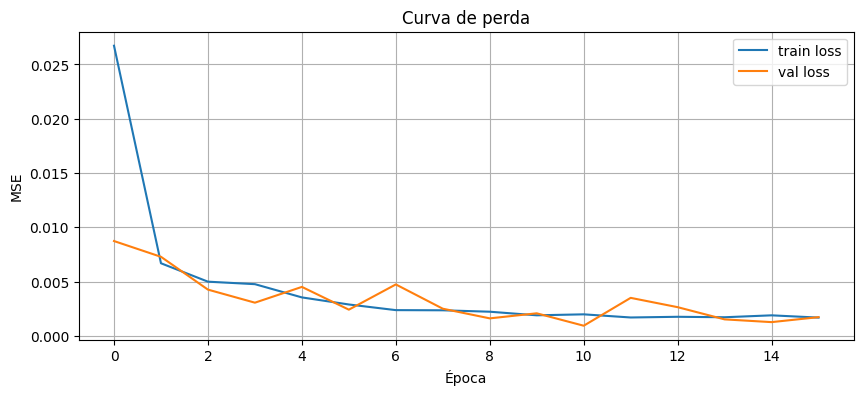

In [0]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Curva de perda")
plt.xlabel("Época"); plt.ylabel("MSE")
plt.legend(); plt.grid(True); plt.show()

## 12. Avaliação no conjunto de teste

- **MAE**: Erro absoluto médio em R$
- **RMSE**: Raiz do erro quadrático médio (penaliza erros grandes)
- **MAPE**: Erro percentual médio (interpretação intuitiva)

In [0]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_scaled = model.predict(X_test, verbose=0)
y_pred  = scaler.inverse_transform(y_pred_scaled)
y_true  = scaler.inverse_transform(y_test.reshape(-1, 1))

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)

print(f"MAE  : R$ {mae:.4f}")
print(f"RMSE : R$ {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

MAE  : R$ 0.5226
RMSE : R$ 0.6901
MAPE : 1.53%


## 13. Real vs previsto (gráfico)

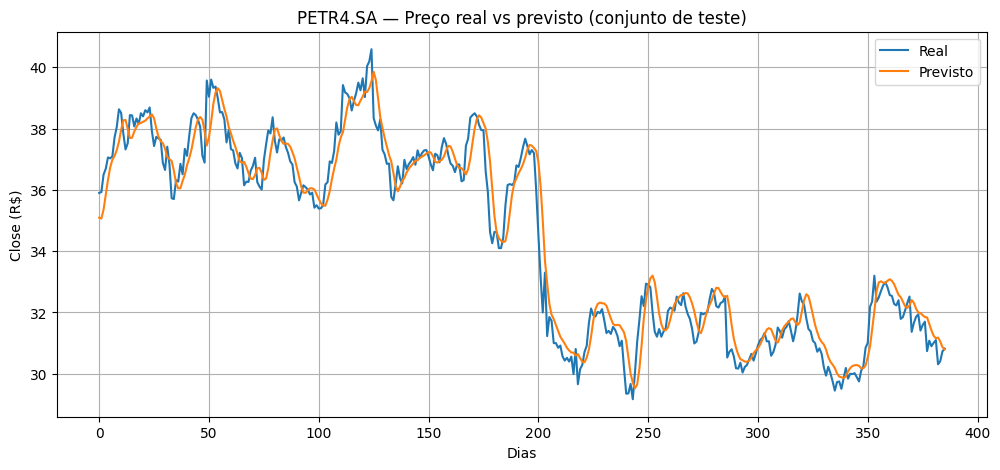

In [0]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="Real")
plt.plot(y_pred, label="Previsto")
plt.title("PETR4.SA — Preço real vs previsto (conjunto de teste)")
plt.xlabel("Dias"); plt.ylabel("Close (R$)")
plt.legend(); plt.grid(True); plt.show()

## 14. Salvar artefatos no volume Unity Catalog

O formato `.keras` é um arquivo zip e o FUSE de UC Volumes não suporta todas as operações necessárias para escrever zips diretamente. Por isso, primeiro salva em `/tmp` e em seguida a cópoa é realizada para o Volume gerenciado pelo Databricks.

In [0]:
import os, pickle, json, shutil

TMP_DIR    = "/tmp/postech_fase4"
VOLUME_DIR = f"/Volumes/{CATALOG}/{SCHEMA}/artefatos"
os.makedirs(TMP_DIR, exist_ok=True)

# 1) Salva no disco local do driver
tmp_model  = f"{TMP_DIR}/lstm_model.keras"
tmp_scaler = f"{TMP_DIR}/scaler.pkl"
tmp_meta   = f"{TMP_DIR}/metadata.json"

model.save(tmp_model)
with open(tmp_scaler, "wb") as f:
    pickle.dump(scaler, f)

metadata = {
    "ticker": "PETR4.SA",
    "window_size": WINDOW,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "best_hyperparameters": {
        "units_1": int(best_hp.get("units_1")),
        "units_2": int(best_hp.get("units_2")),
        "dropout": float(best_hp.get("dropout")),
        "learning_rate": float(best_hp.get("learning_rate")),
    },
    "metrics": {"mae": mae, "rmse": rmse, "mape": mape},
    "data_period": [str(df["date"].min().date()), str(df["date"].max().date())],
    "n_samples_train": int(X_train.shape[0]),
    "n_samples_test": int(X_test.shape[0]),
}
with open(tmp_meta, "w") as f:
    json.dump(metadata, f, indent=2)

# 2) Copia tudo para o volume UC (persistente, sobrevive ao restart do cluster)
for tmp in [tmp_model, tmp_scaler, tmp_meta]:
    destino = f"{VOLUME_DIR}/{os.path.basename(tmp)}"
    shutil.copy(tmp, destino)

print(f"Arquivos copiados para {VOLUME_DIR}:")
for f in os.listdir(VOLUME_DIR):
    print(" -", f)

Arquivos copiados para /Volumes/jessyca_catalog/postech_fase4/artefatos:
 - lstm_model.keras
 - scaler.pkl
 - metadata.json
